# YogAI — Plank Pose Experiment
**Comparative ML Study: Logistic Regression vs SVC vs KNN vs XGBoost**

This notebook runs the full hyperparameter search, cross-validation, and
inference latency benchmark for the **Plank Pose** classifier.

All artifacts (pipeline, label encoder, class map, metadata) are saved to
the working directory so they can be loaded directly during real-video inference.


### Notebook Structure
1. Environment setup & imports  
2. Configuration — Plank Pose  
3. Data loading & validation  
4. Exploratory checks (feature stats)  
5. Experiment loop — all 4 models  
6. Results & benchmark table  
7. Artifact verification  
8. Inference smoke-test (load saved artifacts & predict one sample)


## 1. Environment Setup

In [32]:
# Install dependencies if running for the first time
# Comment out after first run
import subprocess, sys

packages = ["scikit-learn", "xgboost", "pandas", "numpy", "matplotlib",
            "seaborn", "joblib", "pyyaml"]

for pkg in packages:
    subprocess.check_call([sys.executable, "-m", "pip", "install", pkg, "-q"])

print("All dependencies ready.")

All dependencies ready.


In [33]:
import sys
import json
import time
import math
import warnings
import logging
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (
    GridSearchCV, RandomizedSearchCV,
    StratifiedKFold,
    train_test_split,
)

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix,
    ConfusionMatrixDisplay,
)
from xgboost import XGBClassifier

#  Add src/ to path so we can import project modules 
NOTEBOOK_DIR = Path(".").resolve()

# Go up from src/models/training -> project root
PROJECT_ROOT = NOTEBOOK_DIR.parents[2]

SRC_DIR = PROJECT_ROOT / "src"

sys.path.insert(0, str(SRC_DIR))

logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s  %(levelname)-8s  %(message)s",
    datefmt="%H:%M:%S",
)
logger = logging.getLogger(__name__)

print(f"Working directory : {NOTEBOOK_DIR}")
print(f"src/ on path      : {SRC_DIR.exists()}")

Working directory : D:\YogAi_Models_Refactor\src\models\training
src/ on path      : True


## 2. Configuration - Plank Pose


In [35]:
#  Pose identity 
POSE_NAME = "plank_pose"

# Path to the Plank pose CSV (training features)
# Update this to your actual file path if it differs
CSV_PATH = Path("../../../data/processed/engineered_features/plank_pose/plank_train_features.csv")

#  Feature columns (must match CSV headers exactly) 
FEATURE_COLUMNS = [
    "neck_tilt_angle",
    "torso_hip_angle",
    "hip_knee_angle",
    "hip_shoulder_vertical_ratio",
    "plumb_line_alignment"
]

LABEL_COLUMN = "label"

#  Cross-validation settings 
CV_CONFIG = {
    # "n_splits"   : 5,
    "n_splits"   : 5,
    "random_seed": 42,
    "scoring"    : "f1_weighted",
    "n_jobs"     : -1,
}

#  Hyperparameter grids 
# KNN NOTE: n_neighbors must never exceed floor(sqrt(n_training_samples)).
# A runtime warning is raised below if any value violates this.
HYPERPARAMETER_GRIDS = {
    "logistic_regression": {
        "classifier__C"       : [0.01, 0.1, 1.0, 10.0, 100.0],
        "classifier__penalty" : ["l2"],
        "classifier__solver"  : ["lbfgs"],
        "classifier__max_iter": [1000],
    },
    "svc": {
        "classifier__C"     : [0.1, 1.0, 10.0, 100.0],
        "classifier__kernel": ["rbf", "linear"],
        "classifier__gamma" : ["scale", "auto"],
    },
    "knn": {
        "classifier__n_neighbors": [3, 5, 7, 11, 15],
        "classifier__weights"    : ["uniform", "distance"],
        "classifier__metric"     : ["euclidean", "manhattan"],
    },
    "xgboost": {
        "classifier__n_estimators"    : [100, 200, 300],
        "classifier__max_depth"       : [3, 5, 7],
        "classifier__learning_rate"   : [0.01, 0.05, 0.1, 0.2],
        "classifier__subsample"       : [0.7, 0.8, 1.0],
        "classifier__colsample_bytree": [0.7, 0.8, 1.0],
        "classifier__min_child_weight": [1, 3, 5],
    },
}

XGBOOST_RANDOM_SEARCH_ITER = 30
LATENCY_WARMUP_CALLS       = 10
LATENCY_TRIAL_CALLS        = 500

#  Feedback messages per class 
FEEDBACK = {
    "correct"   : "Excellent form! Your body is in a perfect straight line. Keep your core tight.",
    "high_back" : "Lower your hips slightly. Your hips are raised too high, breaking the straight plank line.",
    "low_back"  : "Engage your core and lift your hips up. Do not let your lower back sag toward the floor.",
}

print("Configuration loaded.")
print(f"Pose            : {POSE_NAME}")
print(f"Features        : {FEATURE_COLUMNS}")
print(f"CSV path        : {CSV_PATH}")
print(f"CSV exists      : {CSV_PATH.exists()}")


Configuration loaded.
Pose            : plank_pose
Features        : ['neck_tilt_angle', 'torso_hip_angle', 'hip_knee_angle', 'hip_shoulder_vertical_ratio', 'plumb_line_alignment']
CSV path        : ..\..\..\data\processed\engineered_features\plank_pose\plank_train_features.csv
CSV exists      : True


In [36]:
#  Output folder structure 
# Root is created one level above the notebook file (.. folder)
# Structure:
#   ../plank_pose_files/
#       models/       — .joblib pipeline and label encoder files
#       metadata/     — .json class maps and metadata files
#       results/      — experiment summary CSV
#       images/       — confusion matrix and latency chart PNGs

NOTEBOOK_DIR  = Path(".").resolve()
OUTPUT_ROOT = NOTEBOOK_DIR.parent / "saved_files" / f"{POSE_NAME}_files"

DIR_MODELS    = OUTPUT_ROOT / "models"
DIR_METADATA  = OUTPUT_ROOT / "metadata"
DIR_RESULTS   = OUTPUT_ROOT / "results"
DIR_IMAGES    = OUTPUT_ROOT / "images"

for folder in [DIR_MODELS, DIR_METADATA, DIR_RESULTS, DIR_IMAGES]:
    folder.mkdir(parents=True, exist_ok=True)

print(f"Output root : {OUTPUT_ROOT}")
print(f"  models/   : {DIR_MODELS}")
print(f"  metadata/ : {DIR_METADATA}")
print(f"  results/  : {DIR_RESULTS}")
print(f"  images/   : {DIR_IMAGES}")


Output root : D:\YogAi_Models_Refactor\src\models\saved_files\plank_pose_files
  models/   : D:\YogAi_Models_Refactor\src\models\saved_files\plank_pose_files\models
  metadata/ : D:\YogAi_Models_Refactor\src\models\saved_files\plank_pose_files\metadata
  results/  : D:\YogAi_Models_Refactor\src\models\saved_files\plank_pose_files\results
  images/   : D:\YogAi_Models_Refactor\src\models\saved_files\plank_pose_files\images


## 3. Data Loading & Validation

In [37]:
#  Load CSV 
assert CSV_PATH.exists(), (
    f"CSV not found at '{CSV_PATH}'. "
    f"Update CSV_PATH in the Configuration cell above."
)

df = pd.read_csv(CSV_PATH)
print(f"Raw shape: {df.shape}")
df.head()

Raw shape: (28520, 6)


,label,neck_tilt_angle,torso_hip_angle,hip_knee_angle,hip_shoulder_vertical_ratio,plumb_line_alignment
0,C,88.016181,154.284312,157.030333,0.014750,0.747950
1,C,88.095680,154.132166,157.069513,0.014610,0.750389
2,C,88.137822,154.125484,157.063675,0.014551,0.750643
3,C,88.170670,154.008849,157.064584,0.014455,0.752840
4,C,88.208104,153.922986,157.108223,0.014385,0.753823


In [38]:
#  Validate required columns are present 
required_cols = FEATURE_COLUMNS + [LABEL_COLUMN]
missing_cols  = [c for c in required_cols if c not in df.columns]

if missing_cols:
    raise ValueError(
        f"The following required columns are missing from the CSV: {missing_cols}\n"
        f"Available columns: {list(df.columns)}"
    )

print("All required columns present.")
print(f"\nColumn dtypes:")
print(df[required_cols].dtypes)


All required columns present.

Column dtypes:
neck_tilt_angle                float64
torso_hip_angle                float64
hip_knee_angle                 float64
hip_shoulder_vertical_ratio    float64
plumb_line_alignment           float64
label                              str
dtype: object


In [39]:
#  Check for nulls 
null_counts = df[required_cols].isnull().sum()
null_counts = null_counts[null_counts > 0]

if not null_counts.empty:
    print("WARNING: Null values detected:")
    print(null_counts)
    print("\nDropping rows with nulls...")
    df = df.dropna(subset=FEATURE_COLUMNS + [LABEL_COLUMN])
    print(f"Shape after dropping nulls: {df.shape}")
else:
    print("No null values. Dataset is clean.")

No null values. Dataset is clean.


In [40]:
#  Encode string labels to integers 
# LabelEncoder is fitted here on the full label set so all classes are known.
# The fitted encoder is saved as an artifact — inference must load and use
# this exact encoder to decode predictions back to strings.

label_encoder = LabelEncoder()
y_encoded     = label_encoder.fit_transform(df[LABEL_COLUMN].str.lower().str.strip())

class_map = {idx: cls for idx, cls in enumerate(label_encoder.classes_)}
print("Label encoding:")
for k, v in class_map.items():
    count = (y_encoded == k).sum()
    print(f"  {k} -> '{v}'  ({count} samples, {count/len(y_encoded)*100:.1f}%)")

Label encoding:
  0 -> 'c'  (9904 samples, 34.7%)
  1 -> 'h'  (9070 samples, 31.8%)
  2 -> 'l'  (9546 samples, 33.5%)


**Label encoding will be printed above after running cell 11.**


In [41]:
#  Extract X, y 
X = df[FEATURE_COLUMNS].values
y = y_encoded

n_samples = len(X)

print(f"\nDataset summary")
print(f"  Samples  : {n_samples}")
print(f"  Features : {X.shape[1]}")
print(f"  Classes  : {len(class_map)}")



Dataset summary
  Samples  : 28520
  Features : 5
  Classes  : 3


In [42]:
#  Set experiment tag 
# For plank pose we run a single experiment (3 classes: correct, high_back, low_back)
experiment_tag = "full_class"

print(f"Experiment tag : {experiment_tag}")
print(f"Classes ({len(class_map)}):")
for k, v in class_map.items():
    count = (y == k).sum()
    print(f"  {k} -> '{v}'  ({count} samples)")


Experiment tag : full_class
Classes (3):
  0 -> 'c'  (9904 samples)
  1 -> 'h'  (9070 samples)
  2 -> 'l'  (9546 samples)


## 4. Exploratory Checks


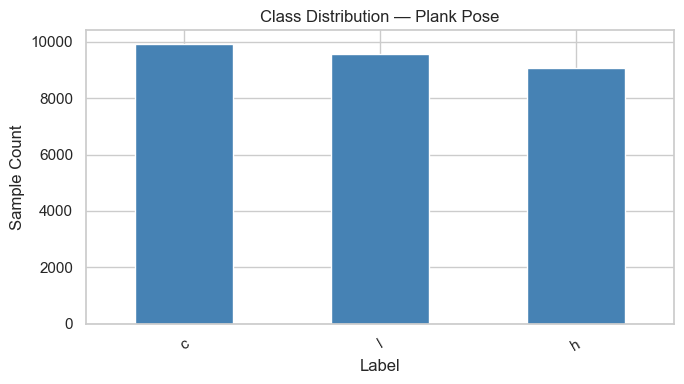

In [43]:
#  Class distribution 
fig, ax = plt.subplots(figsize=(7, 4))

label_strings = label_encoder.inverse_transform(y)
pd.Series(label_strings).value_counts().plot(
    kind="bar", ax=ax, color="steelblue", edgecolor="white"
)
ax.set_title("Class Distribution — Plank Pose")
ax.set_xlabel("Label")
ax.set_ylabel("Sample Count")
ax.tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()


In [44]:
#  Feature statistics 
feature_df = pd.DataFrame(X, columns=FEATURE_COLUMNS)
feature_df.describe().round(4)


,neck_tilt_angle,torso_hip_angle,hip_knee_angle,hip_shoulder_vertical_ratio,plumb_line_alignment
count,28520.0000,28520.0000,28520.0000,28520.0000,28520.0000
mean,97.4889,130.1490,164.5791,0.4363,0.7677
std,13.9360,31.5284,7.8130,0.2638,0.3445
min,71.7453,46.5157,67.2627,0.0000,0.0578
25%,86.7793,97.0689,159.7761,0.1448,0.5051
50%,93.5698,144.4097,165.3594,0.5015,0.6965
75%,107.6583,152.9446,170.1874,0.6356,1.1593
max,164.8186,178.0911,179.6030,0.9252,1.4066


In [45]:
#  Check for angle outliers (optional — adjust thresholds as needed) 
initial_count = len(feature_df)

# Filter rows where any joint angle is outside [0°, 200°] — likely bad MediaPipe detections
angle_cols = [c for c in FEATURE_COLUMNS if "angle" in c]
if angle_cols:
    angle_mask = (feature_df[angle_cols] >= 0).all(axis=1) & (feature_df[angle_cols] <= 200).all(axis=1)
    feature_df = feature_df[angle_mask]

final_count   = len(feature_df)
dropped_count = initial_count - final_count

print(f"--- Angle Outlier Removal Summary ---")
print(f"Initial row count : {initial_count}")
print(f"Rows dropped      : {dropped_count}")
print(f"Final cleaned rows: {final_count}")
print(f"-------------------------------------")


--- Angle Outlier Removal Summary ---
Initial row count : 28520
Rows dropped      : 0
Final cleaned rows: 28520
-------------------------------------


In [46]:
# (Outlier removal already applied in the cell above — no duplicate needed)


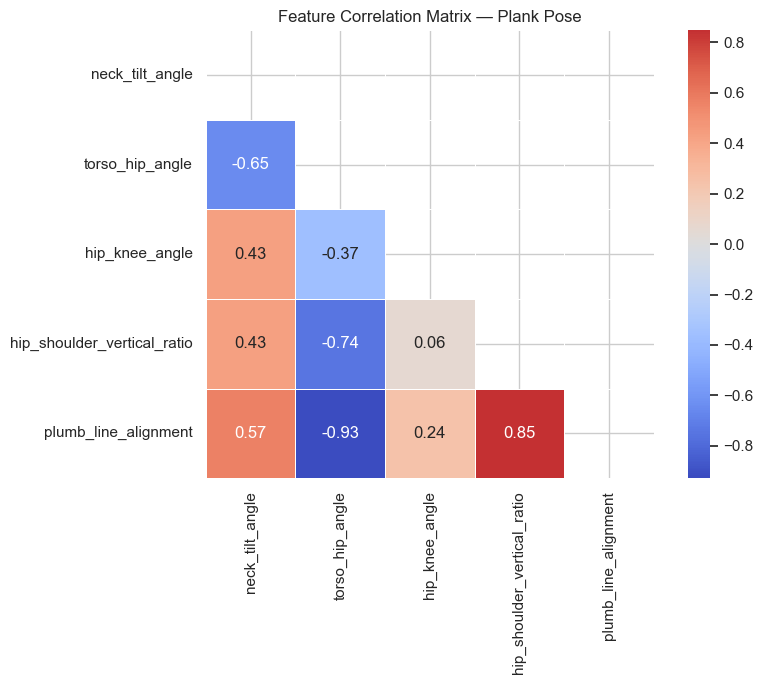

In [47]:
#  Feature correlation heatmap 
fig, ax = plt.subplots(figsize=(9, 7))
corr = feature_df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(
    corr, mask=mask, annot=True, fmt=".2f",
    cmap="coolwarm", center=0, ax=ax,
    linewidths=0.5, square=True,
)
ax.set_title("Feature Correlation Matrix — Plank Pose")
plt.tight_layout()
plt.show()


## 5. Experiment Helpers

In [49]:
def build_pipeline(model_name: str) -> Pipeline:
    """
    Return an unfitted sklearn Pipeline: StandardScaler -> estimator.
    Must be unfitted when passed to GridSearchCV to prevent leakage.
    """
    seed = CV_CONFIG["random_seed"]

    estimators = {
        "logistic_regression": LogisticRegression(random_state=seed, max_iter=1000),
        "svc"                : SVC(random_state=seed, probability=True),
        "knn"                : KNeighborsClassifier(n_neighbors=5),
        "xgboost"            : XGBClassifier(
                                   random_state=seed,
                                   verbosity=0,
                                   eval_metric="mlogloss",
                               ),
    }

    if model_name not in estimators:
        raise ValueError(f"Unknown model '{model_name}'. Choose from {list(estimators)}")

    return Pipeline([
        ("scaler"    , StandardScaler()),
        ("classifier", estimators[model_name]),
    ])


def check_knn_neighbor_cap(n_neighbors_grid: list, n_training_samples: int) -> None:
    """Warn if any n_neighbors value exceeds floor(sqrt(n_training_samples))."""
    ceiling    = math.floor(math.sqrt(n_training_samples))
    oversized  = [k for k in n_neighbors_grid if k > ceiling]
    if oversized:
        warnings.warn(
            f"KNN grid has n_neighbors values {oversized} exceeding the "
            f"recommended ceiling floor(sqrt({n_training_samples})) = {ceiling}. "
            f"Consider trimming the grid.",
            UserWarning, stacklevel=2,
        )


def measure_inference_latency(
    pipeline, X_probe: np.ndarray,
    n_warmup: int = LATENCY_WARMUP_CALLS,
    n_trials: int = LATENCY_TRIAL_CALLS,
) -> dict:
    """
    Measure per-sample prediction latency.
    Warm-up calls are discarded to eliminate cold-start bias.
    p95/p99 are reported because real-time systems are bounded by tail latency.
    """
    for _ in range(n_warmup):
        pipeline.predict(X_probe)

    latencies_ms = np.empty(n_trials)
    for i in range(n_trials):
        t0 = time.perf_counter()
        pipeline.predict(X_probe)
        latencies_ms[i] = (time.perf_counter() - t0) * 1000.0

    return {
        "mean_ms"        : round(float(np.mean(latencies_ms)), 4),
        "std_ms"         : round(float(np.std(latencies_ms)), 4),
        "p95_ms"         : round(float(np.percentile(latencies_ms, 95)), 4),
        "p99_ms"         : round(float(np.percentile(latencies_ms, 99)), 4),
        "implied_max_fps": round(1000.0 / float(np.mean(latencies_ms)), 1),
    }

def load_results_from_disk(pose_name: str, experiment_tag: str, 
                            models: list, DIR_METADATA: Path) -> list:
    """
    Load experiment results from saved metadata JSONs.
    Use this to restore any experiment without re-running.
    """
    results = []
    
    for model_name in models:
        prefix    = f"{pose_name}_{experiment_tag}_{model_name}"
        meta_path = DIR_METADATA / f"{prefix}_metadata.json"
        
        if not meta_path.exists():
            print(f"[WARNING] Missing: {meta_path.name} — skipping")
            continue
            
        with open(meta_path) as f:
            results.append(json.load(f))
            
    print(f"Loaded {len(results)}/{len(models)} models "
          f"for '{pose_name}' — '{experiment_tag}'")
    return results


# Usage — load any experiment by just changing the tag
# all_results_4class = load_results_from_disk(
#     pose_name      = POSE_NAME,
#     experiment_tag = "4class_no_bent_forward",
#     models         = ["logistic_regression", "svc", "knn", "xgboost"],
#     DIR_METADATA   = DIR_METADATA,
# )

# After 5-class run, load that too the same way
# all_results_5class = load_results_from_disk(
#     pose_name      = POSE_NAME,
#     experiment_tag = "5class_full",
#     models         = ["logistic_regression", "svc", "knn", "xgboost"],
#     DIR_METADATA   = DIR_METADATA,
# )

print("Helper functions defined.")

Helper functions defined.


In [50]:
import numpy as np
import pandas as pd

# Initialize Seed
seed = CV_CONFIG["random_seed"]

# 
# Plank pose uses a SEPARATE held-out test CSV.
# Load the test set from its dedicated file.
# 
TEST_CSV_PATH = CSV_PATH.parent / "plank_test_features.csv"

assert TEST_CSV_PATH.exists(), (
    f"Test CSV not found at '{TEST_CSV_PATH}'. "
    f"Make sure plank_test_features.csv is in the same folder as the train CSV."
)

df_test      = pd.read_csv(TEST_CSV_PATH)
missing_test = [c for c in FEATURE_COLUMNS + [LABEL_COLUMN] if c not in df_test.columns]
if missing_test:
    raise ValueError(f"Test CSV is missing columns: {missing_test}")

df_test = df_test.dropna(subset=FEATURE_COLUMNS + [LABEL_COLUMN])

X_test = df_test[FEATURE_COLUMNS].values
y_test = label_encoder.transform(df_test[LABEL_COLUMN].str.lower().str.strip())

# Training set — all rows from the training CSV
X_train = X
y_train = y

print(f"Train: {len(X_train)} samples")
print(f"Test : {len(X_test)} samples  (from {TEST_CSV_PATH.name})")

print("\nTrain class distribution:")
for k, v in class_map.items():
    count = (y_train == k).sum()
    print(f"  {v}: {count} ({count/len(y_train)*100:.1f}%)")

print("\nTest class distribution:")
for k, v in class_map.items():
    count = (y_test == k).sum()
    print(f"  {v}: {count} ({count/len(y_test)*100:.1f}%)")


Train: 28520 samples
Test : 710 samples  (from plank_test_features.csv)

Train class distribution:
  c: 9904 (34.7%)
  h: 9070 (31.8%)
  l: 9546 (33.5%)

Test class distribution:
  c: 234 (33.0%)
  h: 241 (33.9%)
  l: 235 (33.1%)


In [51]:
#  Class balance assessment ─
train_counts = pd.Series(y_train).value_counts().sort_index()
max_count    = train_counts.max()
min_count    = train_counts.min()
imbalance_ratio = max_count / min_count

print(f"Imbalance ratio (max/min): {imbalance_ratio:.2f}")

if imbalance_ratio < 1.5:
    print("Assessment: BALANCED — no resampling or class weighting needed.")
    print("Justification: ratio < 1.5, f1_weighted scoring already accounts")
    print("for minor differences in class support.")
elif imbalance_ratio < 3.0:
    print("Assessment: MILDLY IMBALANCED — consider class_weight='balanced'")
    print("for LogisticRegression and SVC.")
else:
    print("Assessment: IMBALANCED — add class_weight='balanced' to LR and SVC,")
    print("and set scale_pos_weight in XGBoost.")

Imbalance ratio (max/min): 1.09
Assessment: BALANCED — no resampling or class weighting needed.
Justification: ratio < 1.5, f1_weighted scoring already accounts
for minor differences in class support.


## 7. Experiment Loop - All 4 Models

In [52]:
# Assertions before loop
assert seed is not None, "Global seed must be set before the experiment loop"

# StratifiedKFold — preserves class proportions across folds
n_splits_actual = CV_CONFIG["n_splits"]
cv_strategy     = StratifiedKFold(n_splits=n_splits_actual, shuffle=True, random_state=seed)

print(f"CV strategy : StratifiedKFold with {n_splits_actual} splits")
print(f"Scoring     : {CV_CONFIG['scoring']}")
print()

MODELS         = ["logistic_regression", "svc", "knn", "xgboost"]
all_results    = []
best_pipelines = {}

# Constant to avoid magic string
WEIGHTED_AVG_KEY = "weighted avg"

for model_name in MODELS:
    print(f"{'='*60}")
    print(f"  Running: {model_name.upper().replace('_', ' ')}")
    print(f"{'='*60}")

    try:
        # Build unfitted pipeline — scaler must not be fitted before GridSearchCV
        pipeline   = build_pipeline(model_name)
        param_grid = HYPERPARAMETER_GRIDS[model_name]

        # KNN neighbor cap — guard against smallest fold, not full X_train
        if model_name == "knn":
            min_fold_train_size = int(len(X_train) * (n_splits_actual - 1) / n_splits_actual)
            check_knn_neighbor_cap(
                param_grid["classifier__n_neighbors"], min_fold_train_size
            )

        # XGBoost uses RandomizedSearchCV due to larger grid
        if model_name == "xgboost":
            search = RandomizedSearchCV(
                estimator=pipeline,
                param_distributions=param_grid,
                n_iter=XGBOOST_RANDOM_SEARCH_ITER,
                scoring=CV_CONFIG["scoring"],
                cv=cv_strategy,
                n_jobs=CV_CONFIG["n_jobs"],
                random_state=seed,
                refit=True,
                verbose=0,
            )
        else:
            search = GridSearchCV(
                estimator=pipeline,
                param_grid=param_grid,
                scoring=CV_CONFIG["scoring"],
                cv=cv_strategy,
                n_jobs=CV_CONFIG["n_jobs"],
                refit=True,
                verbose=0,
            )

        search.fit(X_train, y_train)

        best_pipeline = search.best_estimator_
        best_pipelines[model_name] = best_pipeline

        # Evaluate on held-out test set
        y_pred   = best_pipeline.predict(X_test)
        clf_dict = classification_report(y_test, y_pred, output_dict=True, zero_division=0)
        clf_str  = classification_report(
                       y_test, y_pred,
                       target_names=list(class_map.values()),
                       zero_division=0,
                   )
        conf_mat = confusion_matrix(y_test, y_pred)

        # Inference latency — 50-sample batch for stable estimates
        X_probe = X_test[:50]
        latency = measure_inference_latency(best_pipeline, X_probe)

        # Result dictionary
        result = {
            "model"                    : model_name,
            "best_cv_score"            : round(search.best_score_, 4),
            "test_f1_weighted"         : round(clf_dict[WEIGHTED_AVG_KEY]["f1-score"], 4),
            "test_precision_weighted"  : round(clf_dict[WEIGHTED_AVG_KEY]["precision"], 4),
            "test_recall_weighted"     : round(clf_dict[WEIGHTED_AVG_KEY]["recall"], 4),
            "test_accuracy"            : round(clf_dict["accuracy"], 4),
            "best_params"              : search.best_params_,
            "classification_report_str": clf_str,
            "confusion_matrix"         : conf_mat,          # raw ndarray — available for ROC plot
            "confusion_matrix_list"    : conf_mat.tolist(), # JSON-serialisable copy
            **latency,
        }

        # Dynamic fold score extraction
        best_index = search.best_index_
        fold_scores = [
            round(search.cv_results_[f"split{i}_test_score"][best_index], 4)
            for i in range(n_splits_actual)
        ]
        result["cv_folds_scores"] = fold_scores

        # Explainable AI — feature importances
        classifier_step = best_pipeline.named_steps["classifier"]
        if model_name == "xgboost":
            result["feature_importances"]     = classifier_step.feature_importances_.tolist()
            result["has_feature_importances"] = True
        elif model_name == "logistic_regression":
            result["feature_importances"]     = np.mean(np.abs(classifier_step.coef_), axis=0).tolist()
            result["has_feature_importances"] = True
        else:
            result["feature_importances"]     = None
            result["has_feature_importances"] = False

        all_results.append(result)

        # Per-model summary
        print(f"Best CV score  : {result['best_cv_score']}")
        print(f"Best params    : {search.best_params_}")
        print()
        print("Classification Report (test set):")
        print(clf_str)
        print(f"Latency  mean={latency['mean_ms']} ms | "
              f"p95={latency['p95_ms']} ms | "
              f"p99={latency['p99_ms']} ms | "
              f"implied FPS={latency['implied_max_fps']}")

        # Save artifacts immediately after each model
        prefix = f"{POSE_NAME}_{experiment_tag}_{model_name}"

        joblib.dump(best_pipeline, DIR_MODELS / f"{prefix}_pipeline.joblib")
        joblib.dump(label_encoder, DIR_MODELS / f"{prefix}_label_encoder.joblib")

        with open(DIR_METADATA / f"{prefix}_class_map.json", "w") as f:
            json.dump({str(k): v for k, v in class_map.items()}, f, indent=2)

        metadata = {
            "pose"                 : POSE_NAME,
            "experiment_tag"       : experiment_tag,
            "model"                : model_name,
            "feature_columns"      : FEATURE_COLUMNS,
            "n_features"           : len(FEATURE_COLUMNS),
            "best_params"          : search.best_params_,
            "best_cv_score"        : result["best_cv_score"],
            "cv_folds_scores"      : fold_scores,
            "test_f1_weighted"     : result["test_f1_weighted"],
            "test_accuracy"        : result["test_accuracy"],
            "n_train"              : len(X_train),
            "n_test"               : len(X_test),
            "cv_config"            : CV_CONFIG,
            "class_map"            : {str(k): v for k, v in class_map.items()},
            "latency"              : latency,
            "confusion_matrix"     : conf_mat.tolist(),
            "classification_report": clf_str,
        }

        with open(DIR_METADATA / f"{prefix}_metadata.json", "w") as f:
            json.dump(metadata, f, indent=2)

        print(f"Artifacts saved to {OUTPUT_ROOT.name}/")
        print(f"  models/   {prefix}_pipeline.joblib")
        print(f"  models/   {prefix}_label_encoder.joblib")
        print(f"  metadata/ {prefix}_class_map.json")
        print(f"  metadata/ {prefix}_metadata.json")
        print()

    except Exception as e:
        print(f"[ERROR] {model_name} failed — skipping. Reason: {e}")
        continue

print("All Experiments Completed.")


CV strategy : StratifiedKFold with 5 splits
Scoring     : f1_weighted

  Running: LOGISTIC REGRESSION


d:\YogAi_Models_Refactor\venv_yogai\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


Best CV score  : 0.9967
Best params    : {'classifier__C': 100.0, 'classifier__max_iter': 1000, 'classifier__penalty': 'l2', 'classifier__solver': 'lbfgs'}

Classification Report (test set):
              precision    recall  f1-score   support

           c       0.97      1.00      0.99       234
           h       1.00      1.00      1.00       241
           l       1.00      0.98      0.99       235

    accuracy                           0.99       710
   macro avg       0.99      0.99      0.99       710
weighted avg       0.99      0.99      0.99       710

Latency  mean=0.198 ms | p95=0.3802 ms | p99=0.6699 ms | implied FPS=5050.1
Artifacts saved to plank_pose_files/
  models/   plank_pose_full_class_logistic_regression_pipeline.joblib
  models/   plank_pose_full_class_logistic_regression_label_encoder.joblib
  metadata/ plank_pose_full_class_logistic_regression_class_map.json
  metadata/ plank_pose_full_class_logistic_regression_metadata.json

  Running: SVC
Best CV score  : 

d:\YogAi_Models_Refactor\venv_yogai\Lib\site-packages\joblib\externals\loky\process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Best CV score  : 0.9977
Best params    : {'classifier__subsample': 1.0, 'classifier__n_estimators': 300, 'classifier__min_child_weight': 3, 'classifier__max_depth': 7, 'classifier__learning_rate': 0.05, 'classifier__colsample_bytree': 1.0}

Classification Report (test set):
              precision    recall  f1-score   support

           c       0.99      1.00      0.99       234
           h       1.00      1.00      1.00       241
           l       1.00      0.99      1.00       235

    accuracy                           1.00       710
   macro avg       1.00      1.00      1.00       710
weighted avg       1.00      1.00      1.00       710

Latency  mean=1.8064 ms | p95=2.2421 ms | p99=2.3609 ms | implied FPS=553.6
Artifacts saved to plank_pose_files/
  models/   plank_pose_full_class_xgboost_pipeline.joblib
  models/   plank_pose_full_class_xgboost_label_encoder.joblib
  metadata/ plank_pose_full_class_xgboost_class_map.json
  metadata/ plank_pose_full_class_xgboost_metadata.js

## 8. Results & Benchmark Table


In [57]:
#  Flat benchmark table ─
benchmark_cols = [
    "model", "best_cv_score",
    "test_f1_weighted", "test_precision_weighted",
    "test_recall_weighted", "test_accuracy",
    "mean_ms", "p95_ms", "p99_ms", "implied_max_fps",
]

results_df = pd.DataFrame(all_results)[benchmark_cols]
results_df = results_df.sort_values("test_f1_weighted", ascending=False).reset_index(drop=True)

csv_path = DIR_RESULTS / f"{POSE_NAME}_{experiment_tag}_experiment_results.csv"
results_df.to_csv(csv_path, index=False)
print(f"Results saved to {OUTPUT_ROOT.name}/results/{csv_path.name}")
print()
results_df

Results saved to plank_pose_files/results/plank_pose_full_class_experiment_results.csv



,model,best_cv_score,test_f1_weighted,test_precision_weighted,test_recall_weighted,test_accuracy,mean_ms,p95_ms,p99_ms,implied_max_fps
0,xgboost,0.9977,0.9958,0.9958,0.9958,0.9958,1.8064,2.2421,2.3609,553.6
1,knn,0.9978,0.9930,0.9931,0.9930,0.9930,2.1425,3.1020,3.6265,466.7
2,svc,0.9973,0.9916,0.9918,0.9915,0.9915,1.0540,1.6513,2.0144,948.7
3,logistic_regression,0.9967,0.9916,0.9918,0.9915,0.9915,0.1980,0.3802,0.6699,5050.1


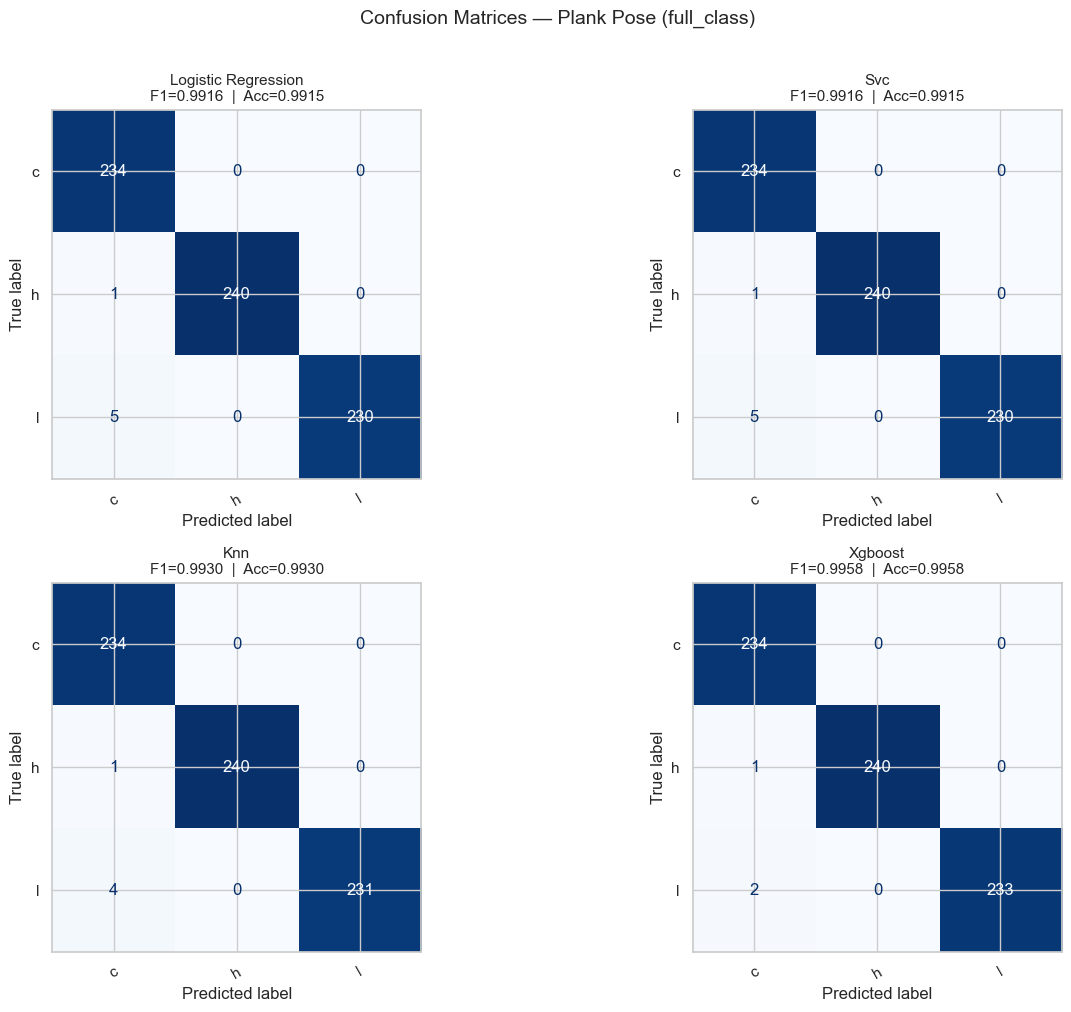

Saved -> plank_pose_files/images/plank_pose_full_class_confusion_matrices.png


In [58]:
#  Confusion matrices — all 4 models ─
fig, axes   = plt.subplots(2, 2, figsize=(14, 10))
axes        = axes.flatten()
class_names = list(class_map.values())

for i, result in enumerate(all_results):
    disp = ConfusionMatrixDisplay(
        confusion_matrix=result["confusion_matrix"],
        display_labels=class_names,
    )
    disp.plot(ax=axes[i], colorbar=False, cmap="Blues")
    axes[i].set_title(
        f"{result['model'].replace('_', ' ').title()}\n"
        f"F1={result['test_f1_weighted']:.4f}  |  "
        f"Acc={result['test_accuracy']:.4f}",
        fontsize=11,
    )
    axes[i].tick_params(axis="x", rotation=30)

plt.suptitle(
    f"Confusion Matrices — {POSE_NAME.replace('_', ' ').title()} ({experiment_tag})",
    fontsize=14, y=1.01,
)
plt.tight_layout()

img_path = DIR_IMAGES / f"{POSE_NAME}_{experiment_tag}_confusion_matrices.png"
plt.savefig(img_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved -> {OUTPUT_ROOT.name}/images/{img_path.name}")

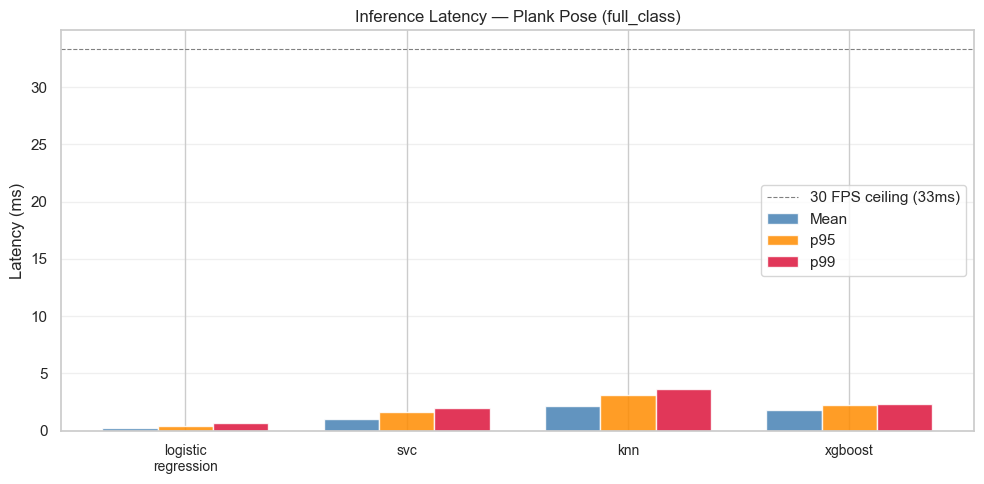

Saved -> plank_pose_files/images/plank_pose_full_class_latency_comparison.png


In [59]:
#  Latency comparison bar chart ─
fig, ax = plt.subplots(figsize=(10, 5))

model_labels = [r["model"].replace("_", "\n") for r in all_results]
mean_vals    = [r["mean_ms"] for r in all_results]
p95_vals     = [r["p95_ms"]  for r in all_results]
p99_vals     = [r["p99_ms"]  for r in all_results]

x     = np.arange(len(model_labels))
width = 0.25

ax.bar(x - width, mean_vals, width, label="Mean", color="steelblue",  alpha=0.85)
ax.bar(x,         p95_vals,  width, label="p95",  color="darkorange", alpha=0.85)
ax.bar(x + width, p99_vals,  width, label="p99",  color="crimson",    alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels(model_labels, fontsize=10)
ax.set_ylabel("Latency (ms)")
ax.set_title(
    f"Inference Latency — {POSE_NAME.replace('_', ' ').title()} ({experiment_tag})"
)
ax.axhline(y=33.3, color="gray", linestyle="--", linewidth=0.8, label="30 FPS ceiling (33ms)")
ax.legend()
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()

img_path = DIR_IMAGES / f"{POSE_NAME}_{experiment_tag}_latency_comparison.png"
plt.savefig(img_path, dpi=150)
plt.show()
print(f"Saved -> {OUTPUT_ROOT.name}/images/{img_path.name}")

## GroupKFold Stability Distribution Visual

C:\Users\Acer\AppData\Local\Temp\ipykernel_6892\1197904908.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


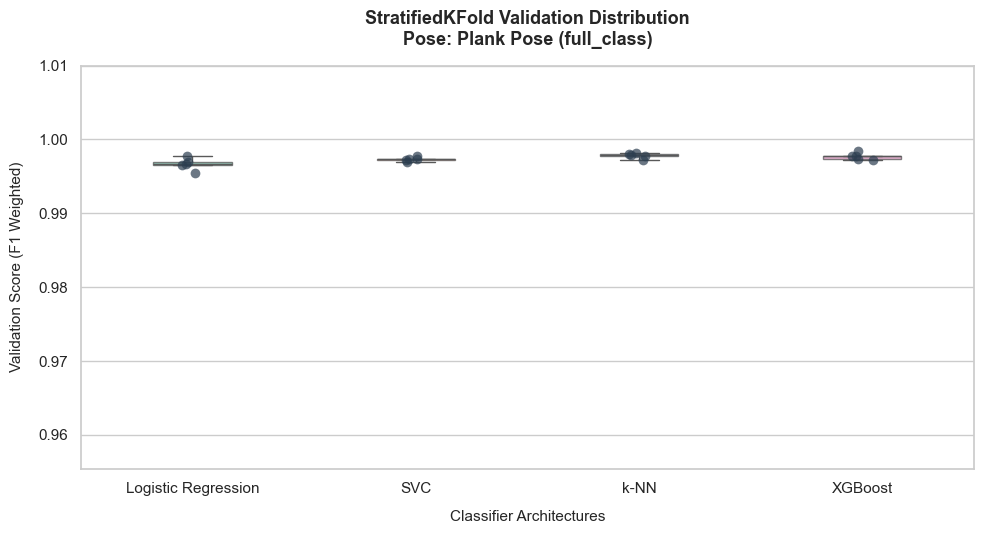

Saved publication-grade plot to: plank_pose_files/images/plank_pose_full_class_stratifiedkfold_variance.png


In [60]:

# Structure raw data into a DataFrame
cv_box_data = {r["model"]: r["cv_folds_scores"] for r in all_results}
df_cv_box = pd.DataFrame(cv_box_data)

# Map snake_case model names to formal academic typography
formal_names = {
    "logistic_regression": "Logistic Regression",
    "svc": "SVC",
    "knn": "k-NN",
    "xgboost": "XGBoost"
}
df_cv_box.columns = [formal_names.get(col, col) for col in df_cv_box.columns]

# Melt data for Seaborn processing
df_cv_melted = df_cv_box.melt(var_name='Model', value_name='Cross-Val Score')

# Setup visualization canvas
fig, ax = plt.subplots(figsize=(10, 5.5))
sns.set_theme(style="whitegrid")

# Draw boxes — showfliers=False removes duplicate outlier circles
sns.boxplot(
    data=df_cv_melted, 
    x='Model', 
    y='Cross-Val Score', 
    palette='Set2', 
    width=0.35, 
    showfliers=False,
    ax=ax,
    boxprops=dict(alpha=0.75)
)

# Overlay individual fold markers transparently
sns.stripplot(
    data=df_cv_melted, 
    x='Model', 
    y='Cross-Val Score', 
    color='#2c3e50', 
    alpha=0.7, 
    size=7, 
    jitter=0.05, 
    ax=ax
)

# Academic formatting and labeling adjustments
scoring_name = CV_CONFIG['scoring'].replace('_', ' ').title()
ax.set_title(
    f"StratifiedKFold Validation Distribution\n"
    f"Pose: {POSE_NAME.replace('_', ' ').title()} ({experiment_tag})", 
    fontsize=13, 
    pad=15, 
    weight='bold'
)
ax.set_ylabel(f"Validation Score ({scoring_name})", fontsize=11, labelpad=10)
ax.set_xlabel("Classifier Architectures", fontsize=11, labelpad=10)

# Zoom in vertically to match your data range seamlessly
min_val = df_cv_melted['Cross-Val Score'].min()
ax.set_ylim(max(0.0, min_val - 0.04), 1.01)

plt.tight_layout()

# Save publication-quality artifact (300 DPI is standard for print layout)
box_img_path = DIR_IMAGES / f"{POSE_NAME}_{experiment_tag}_stratifiedkfold_variance.png"
plt.savefig(box_img_path, dpi=300, bbox_inches="tight")
plt.show()

print(f"Saved publication-grade plot to: {OUTPUT_ROOT.name}/images/{box_img_path.name}")

## Diagnostic

In [61]:
# Diagnostic — fold class coverage check
from sklearn.model_selection import StratifiedKFold
import pandas as pd

skf = StratifiedKFold(n_splits=n_splits_actual, shuffle=True, random_state=seed)

print(f"Total train samples : {len(X_train)}")
print()

fold_diagnostics = []

for fold_idx, (tr_idx, val_idx) in enumerate(skf.split(X_train, y_train)):
    val_labels   = y_train[val_idx]
    class_counts = {class_map[k]: int((val_labels == k).sum()) for k in sorted(class_map)}
    smallest_class = min(class_counts.values())

    fold_diagnostics.append({
        "fold"          : fold_idx,
        "val_samples"   : len(val_idx),
        "smallest_class": smallest_class,
        **class_counts,
    })

    print(f"Fold {fold_idx}  |  val_samples={len(val_idx)}")
    for cls, cnt in class_counts.items():
        print(f"         {cls:<22}: {cnt}")
    print()

df_folds = pd.DataFrame(fold_diagnostics)
print("Summary:")
print(df_folds)


Total train samples : 28520

Fold 0  |  val_samples=5704
         c                     : 1981
         h                     : 1814
         l                     : 1909

Fold 1  |  val_samples=5704
         c                     : 1981
         h                     : 1814
         l                     : 1909

Fold 2  |  val_samples=5704
         c                     : 1981
         h                     : 1814
         l                     : 1909

Fold 3  |  val_samples=5704
         c                     : 1981
         h                     : 1814
         l                     : 1909

Fold 4  |  val_samples=5704
         c                     : 1980
         h                     : 1814
         l                     : 1910

Summary:
   fold  val_samples  smallest_class     c     h     l
0     0         5704            1814  1981  1814  1909
1     1         5704            1814  1981  1814  1909
2     2         5704            1814  1981  1814  1909
3     3         5704       

In [62]:
for n_splits in [5, 3]:
    print(f"\n{'='*40}")
    print(f"Testing n_splits = {n_splits}")
    print(f"{'='*40}")

    skf   = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=seed)
    clean = True

    for fold_idx, (tr_idx, val_idx) in enumerate(skf.split(X_train, y_train)):
        val_labels   = y_train[val_idx]
        class_counts = {class_map[k]: int((val_labels == k).sum()) for k in sorted(class_map)}
        zeros        = [cls for cls, cnt in class_counts.items() if cnt == 0]

        status = "✓" if not zeros else f"✗  ZERO: {zeros}"
        print(f"  Fold {fold_idx}: {class_counts}  {status}")

        if zeros:
            clean = False

    print(f"  → {'CLEAN — safe to use' if clean else 'HAS EMPTY FOLDS — do not use'}")



Testing n_splits = 5
  Fold 0: {'c': 1981, 'h': 1814, 'l': 1909}  ✓
  Fold 1: {'c': 1981, 'h': 1814, 'l': 1909}  ✓
  Fold 2: {'c': 1981, 'h': 1814, 'l': 1909}  ✓
  Fold 3: {'c': 1981, 'h': 1814, 'l': 1909}  ✓
  Fold 4: {'c': 1980, 'h': 1814, 'l': 1910}  ✓
  → CLEAN — safe to use

Testing n_splits = 3
  Fold 0: {'c': 3302, 'h': 3023, 'l': 3182}  ✓
  Fold 1: {'c': 3301, 'h': 3024, 'l': 3182}  ✓
  Fold 2: {'c': 3301, 'h': 3023, 'l': 3182}  ✓
  → CLEAN — safe to use


## Global Structural Feature Importance Chart

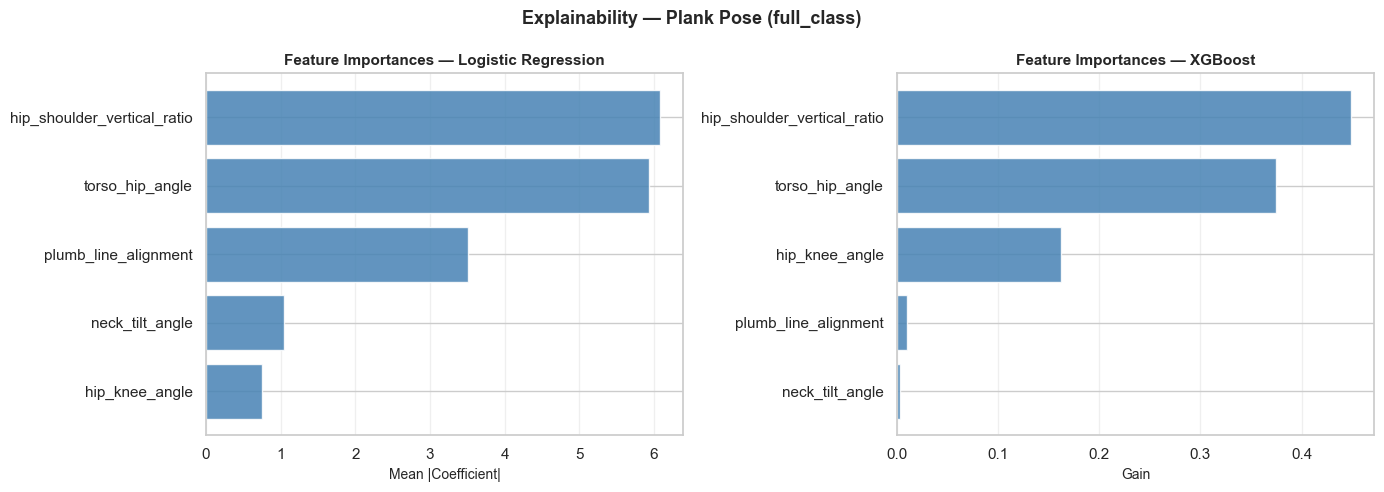

In [63]:
# # Pull out XGBoost or Logistic Regression profile results for explainable AI metrics
# xgb_res = next((item for item in all_results if item["model"] == "xgboost"), None)

# if xgb_res and xgb_res.get("feature_importances") is not None:
#     df_feat = pd.DataFrame({
#         "Feature": FEATURE_COLUMNS,
#         "Relative Importance": xgb_res["feature_importances"]
#     }).sort_values("Relative Importance", ascending=False).head(15) # Top 15 key points
    
#     fig, ax = plt.subplots(figsize=(10, 6))
#     sns.barplot(data=df_feat, x="Relative Importance", y="Feature", palette="flare", ax=ax)
#     ax.set_title(f"Top Spatial Structural Features Driven by XGBoost (Pose Validation)", fontsize=12, pad=12)
#     ax.set_xlabel("Relative Spatial Importance Metric")
#     plt.tight_layout()
    
#     feat_img_path = DIR_IMAGES / f"{POSE_NAME}_{experiment_tag}_feature_importance.png"
#     plt.savefig(feat_img_path, dpi=150)
#     plt.show()
#     print(f"Saved -> {OUTPUT_ROOT.name}/images/{feat_img_path.name}")


fig, axes = plt.subplots(1, 2, figsize=(14, 5))
importance_models = [r for r in all_results if r["has_feature_importances"]]

for ax, result in zip(axes, importance_models):
    importances = np.array(result["feature_importances"])
    sorted_idx  = np.argsort(importances)

    ax.barh(
        [FEATURE_COLUMNS[i] for i in sorted_idx],
        importances[sorted_idx],
        color="steelblue", alpha=0.85
    )
    formal = {"logistic_regression": "Logistic Regression", "xgboost": "XGBoost"}
    ax.set_title(f"Feature Importances — {formal[result['model']]}", fontsize=11, weight="bold")
    ax.set_xlabel("Mean |Coefficient|" if result["model"] == "logistic_regression" else "Gain", fontsize=10)
    ax.grid(axis="x", alpha=0.3)

plt.suptitle(
    f"Explainability — {POSE_NAME.replace('_', ' ').title()} ({experiment_tag})",
    fontsize=13, weight="bold"
)
plt.tight_layout()
plt.savefig(DIR_IMAGES / f"{POSE_NAME}_{experiment_tag}_feature_importances.png", dpi=300, bbox_inches="tight")
plt.show()

## ONE-VS-REST MULTICLASS ROC CURVES

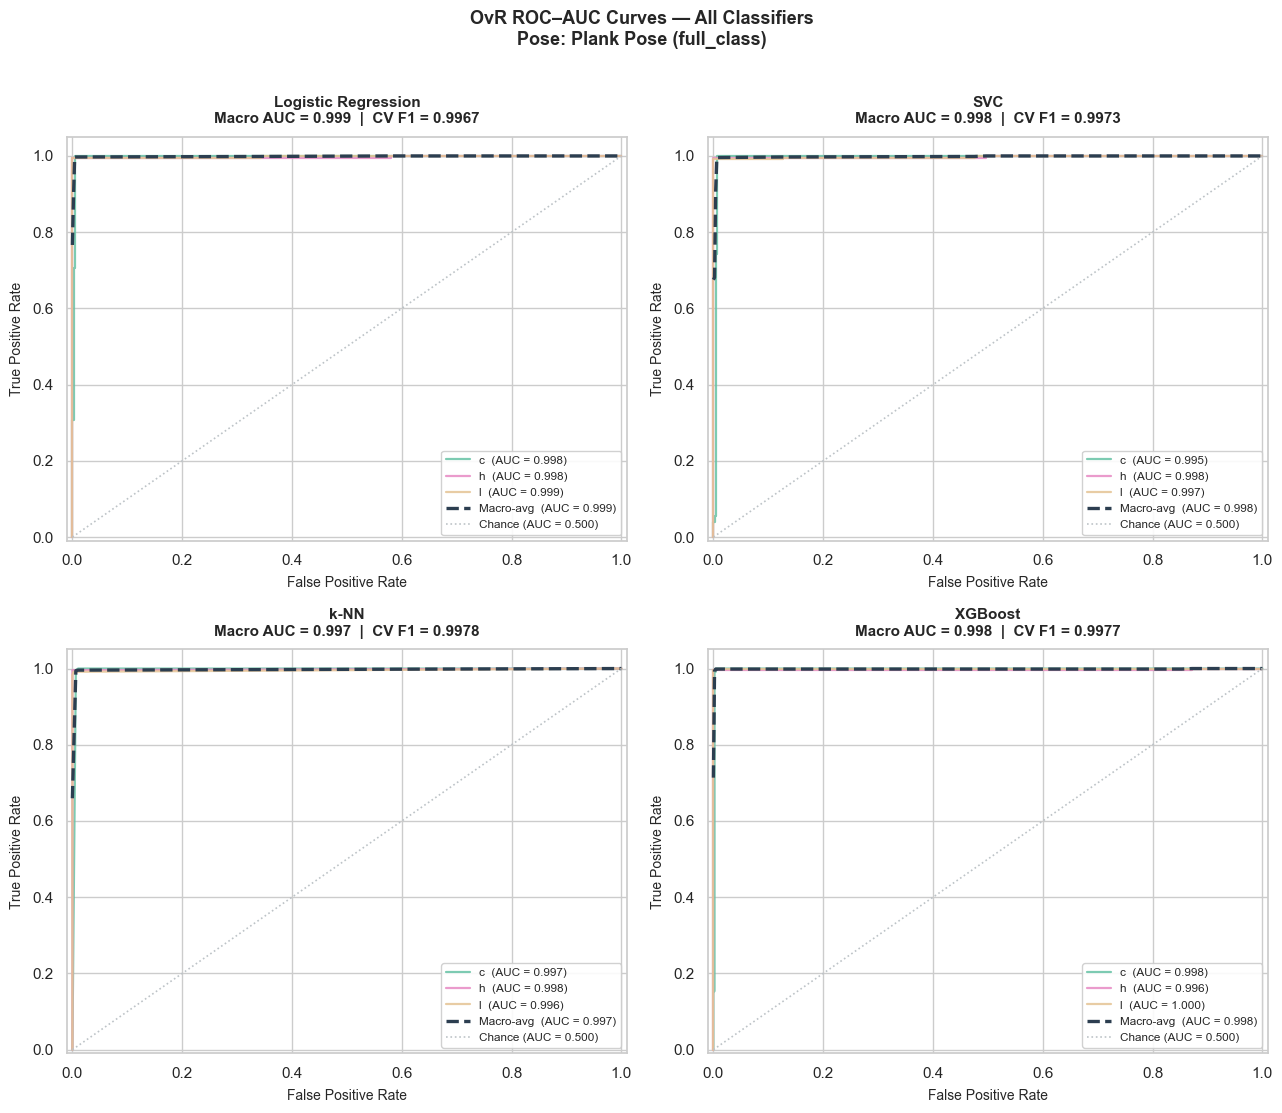

Saved ROC-AUC plot → plank_pose_files/images/plank_pose_full_class_roc_auc_curves.png


In [64]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

# Binarize ground-truth once
classes      = sorted(class_map.keys())
class_labels = [class_map[c] for c in classes]
n_classes    = len(classes)
y_bin        = label_binarize(y_test, classes=classes)

formal_names = {
    "logistic_regression": "Logistic Regression",
    "svc": "SVC",
    "knn": "k-NN",
    "xgboost": "XGBoost",
}

fig, axes = plt.subplots(2, 2, figsize=(13, 11))
sns.set_theme(style="whitegrid")
axes_flat         = axes.flatten()
per_class_palette = plt.cm.Set2(np.linspace(0, 0.85, n_classes))

for ax_idx, result in enumerate(all_results):
    model_name    = result["model"]
    best_pipeline = best_pipelines[model_name]
    ax            = axes_flat[ax_idx]

    # Probability scores — fall back to decision_function for SVC without probability=True
    if hasattr(best_pipeline, "predict_proba"):
        y_score = best_pipeline.predict_proba(X_test)
    else:
        from sklearn.preprocessing import MinMaxScaler
        y_score = MinMaxScaler().fit_transform(
            best_pipeline.decision_function(X_test)
        )

    # Per-class ROC
    fpr, tpr, roc_auc = {}, {}, {}
    for i in range(n_classes):
        fpr[i], tpr[i], _ = roc_curve(y_bin[:, i], y_score[:, i])
        roc_auc[i]        = auc(fpr[i], tpr[i])

    # Macro average
    all_fpr  = np.unique(np.concatenate([fpr[i] for i in range(n_classes)]))
    mean_tpr = np.mean([np.interp(all_fpr, fpr[i], tpr[i]) for i in range(n_classes)], axis=0)
    macro_auc = auc(all_fpr, mean_tpr)

    # Plot per-class curves
    for i, label in enumerate(class_labels):
        ax.plot(fpr[i], tpr[i], color=per_class_palette[i], lw=1.6, alpha=0.85,
                label=f"{label}  (AUC = {roc_auc[i]:.3f})")

    # Macro average + chance diagonal
    ax.plot(all_fpr, mean_tpr, color="#2c3e50", lw=2.4, linestyle="--",
            label=f"Macro-avg  (AUC = {macro_auc:.3f})")
    ax.plot([0, 1], [0, 1], color="#bdc3c7", lw=1.2, linestyle=":",
            label="Chance (AUC = 0.500)")

    ax.set_xlim([-0.01, 1.01])
    ax.set_ylim([-0.01, 1.05])
    ax.set_xlabel("False Positive Rate", fontsize=10, labelpad=6)
    ax.set_ylabel("True Positive Rate", fontsize=10, labelpad=6)
    ax.set_title(
        f"{formal_names.get(model_name, model_name)}\n"
        f"Macro AUC = {macro_auc:.3f}  |  CV F1 = {result['best_cv_score']:.4f}",
        fontsize=11, weight="bold", pad=10,
    )
    ax.legend(fontsize=8.5, loc="lower right", framealpha=0.9)

fig.suptitle(
    f"OvR ROC–AUC Curves — All Classifiers\n"
    f"Pose: {POSE_NAME.replace('_', ' ').title()} ({experiment_tag})",
    fontsize=13, weight="bold", y=1.01,
)
plt.tight_layout()

roc_img_path = DIR_IMAGES / f"{POSE_NAME}_{experiment_tag}_roc_auc_curves.png"
plt.savefig(roc_img_path, dpi=300, bbox_inches="tight")
plt.show()
print(f"Saved ROC-AUC plot → {OUTPUT_ROOT.name}/images/{roc_img_path.name}")

## 9. Artifact Verification

In [29]:
#  Confirm all expected artifacts were written to disk ─
expected_files = []
for model_name in MODELS:
    prefix = f"{POSE_NAME}_{experiment_tag}_{model_name}"
    expected_files += [
        (DIR_MODELS    / f"{prefix}_pipeline.joblib"),
        (DIR_MODELS    / f"{prefix}_label_encoder.joblib"),
        (DIR_METADATA  / f"{prefix}_class_map.json"),
        (DIR_METADATA  / f"{prefix}_metadata.json"),
    ]

expected_files += [
    DIR_RESULTS / f"{POSE_NAME}_{experiment_tag}_experiment_results.csv",
    DIR_IMAGES  / f"{POSE_NAME}_{experiment_tag}_confusion_matrices.png",
    DIR_IMAGES  / f"{POSE_NAME}_{experiment_tag}_latency_comparison.png",
]

all_ok = True
for fpath in expected_files:
    exists  = fpath.exists()
    status  = "OK"      if exists else "MISSING"
    folder  = fpath.parent.name
    if not exists:
        all_ok = False
    print(f"  [{status}]  {folder}/{fpath.name}")

print()
print("All artifacts present." if all_ok else "WARNING: Some artifacts are missing.")

  [OK]  models/plank_pose_full_class_logistic_regression_pipeline.joblib
  [OK]  models/plank_pose_full_class_logistic_regression_label_encoder.joblib
  [OK]  metadata/plank_pose_full_class_logistic_regression_class_map.json
  [OK]  metadata/plank_pose_full_class_logistic_regression_metadata.json
  [OK]  models/plank_pose_full_class_svc_pipeline.joblib
  [OK]  models/plank_pose_full_class_svc_label_encoder.joblib
  [OK]  metadata/plank_pose_full_class_svc_class_map.json
  [OK]  metadata/plank_pose_full_class_svc_metadata.json
  [OK]  models/plank_pose_full_class_knn_pipeline.joblib
  [OK]  models/plank_pose_full_class_knn_label_encoder.joblib
  [OK]  metadata/plank_pose_full_class_knn_class_map.json
  [OK]  metadata/plank_pose_full_class_knn_metadata.json
  [OK]  models/plank_pose_full_class_xgboost_pipeline.joblib
  [OK]  models/plank_pose_full_class_xgboost_label_encoder.joblib
  [OK]  metadata/plank_pose_full_class_xgboost_class_map.json
  [OK]  metadata/plank_pose_full_class_xgboos

## 10. Inference Smoke-Test

Loads the saved artifacts for the **best-performing model** and runs a
prediction on a single sample — exactly replicating what the real-video
inference script will do.

This verifies the full round-trip:
`raw features → load pipeline → predict → decode label`


In [66]:
# #  Pick the best model by test F1 
# best_model_name = results_df.iloc[0]["model"]

# prefix = (
#     f"{POSE_NAME}_{experiment_tag}_{best_model_name}"
# )

# print(
#     f"Best model: {best_model_name} "
#     f"(F1={results_df.iloc[0]['test_f1_weighted']:.4f})"
# )
# print()

# #  Load artifacts from disk ─
# loaded_pipeline = joblib.load(
#     DIR_MODELS / f"{prefix}_pipeline.joblib"
# )

# loaded_encoder = joblib.load(
#     DIR_MODELS / f"{prefix}_label_encoder.joblib"
# )

# with open(
#     DIR_METADATA / f"{prefix}_class_map.json",
#     "r"
# ) as f:
#     loaded_class_map = json.load(f)

# with open(
#     DIR_METADATA / f"{prefix}_metadata.json",
#     "r"
# ) as f:
#     loaded_metadata = json.load(f)

# print("Loaded artifacts:")
# print(f"  Pipeline       : {loaded_pipeline}")
# print(f"  Label encoder  : classes = {list(loaded_encoder.classes_)}")
# print(f"  Feature columns: {loaded_metadata['feature_columns']}")
# print()

# #  Run a prediction on one test sample ─
# # In real-video inference: replace this with MediaPipe-extracted features

# sample_features = X_test[0:1]   # shape (1, n_features)

# raw_pred = loaded_pipeline.predict(sample_features)

# decoded_label = loaded_encoder.inverse_transform(raw_pred)[0]

# true_label = loaded_encoder.inverse_transform([y_test[0]])[0]

# print(f"Sample features  : {sample_features[0]}")
# print(f"Predicted (int)  : {raw_pred[0]}")
# print(f"Predicted (label): '{decoded_label}'")
# print(f"True label       : '{true_label}'")
# print()

# print(
#     "Smoke-test passed."
#     if decoded_label is not None
#     else "Smoke-test FAILED."
# )